In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
# ===========================================
# IMPORT LIBRARIES
# ===========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
# ===========================================
# LOAD DATASET (KAGGLE)
# ===========================================

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print(train.shape)
print(test.shape)

(2000, 8)
(500, 7)


# Display Basic Information

In [4]:
# ===========================================
# BASIC INFORMATION
# ===========================================

print("=" * 60)
print("Training Dataset Information")
print("=" * 60)

train.info()

print("\n")

print("=" * 60)
print("Testing Dataset Information")
print("=" * 60)

test.info()

Training Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


Testing Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    ob

## Check Dataset Shape

In [5]:
print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

Train Shape : (2000, 8)
Test Shape  : (500, 7)


# View Random Samples
### Why?
Looking at only the first five rows isn't enough.
Sometimes important patterns appear later in the dataset.

In [6]:
train.sample(5, random_state=42)

,id,prompt,A,B,C,D,E,answer
1860,1861,Select the most accurate option: What is the p...,The propagation constant is a measure of the a...,The propagation constant is a real number that...,The propagation constant is a real number that...,The propagation constant is a complex number t...,The propagation constant is a complex number t...,D
353,354,Pick the best possible answer: What is the mos...,The pressure differential between the inside a...,The reduce in velocity resulting in an boost i...,The movement of air across the outside surface...,The use of cold water,Bernoulli's principle,E
1333,1334,Pick the best possible answer: What is the Kel...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,A
905,906,Identify the correct statement: What is a cros...,An experiment that involves crossing over two ...,A type of experiment used to distinguish betwe...,An experiment that involves crossing over two ...,An experiment that involves crossing over two ...,An experiment that involves crossing over two ...,B
1289,1290,Choose the correct answer: What is the relatio...,Cometary chemistry is responsible for the form...,Interstellar and cometary chemistry are the sa...,There is a possible connection between interst...,There is no relationship between interstellar ...,Interstellar chemistry is responsible for the ...,C


## Check Missing Values

In [7]:
# ===========================================
# MISSING VALUES
# ===========================================

missing_values = train.isnull().sum()

print(missing_values)

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


In [8]:
# better version of showing the missing value is int he percentage 
missing_percentage = (
    train.isnull().sum() / len(train)
) * 100

missing_df = pd.DataFrame({
    "Missing Values": train.isnull().sum(),
    "Percentage": missing_percentage
})

missing_df

,Missing Values,Percentage
id,0,0.0
prompt,0,0.0
A,0,0.0
B,0,0.0
C,0,0.0
D,0,0.0
E,0,0.0
answer,0,0.0


# Check Duplicate Rows

In [9]:
duplicates = train.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


# check the datatypes 

In [10]:
train.dtypes

id         int64
prompt    object
A         object
B         object
C         object
D         object
E         object
answer    object
dtype: object

In [11]:
# now we will see the number of unique valeus 
print(train["answer"].unique())

['B' 'A' 'C' 'E' 'D']


In [12]:
# now we will count the sample per class 
answer_counts = train["answer"].value_counts()

print(answer_counts)

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


# visualization for the count of each unique values 

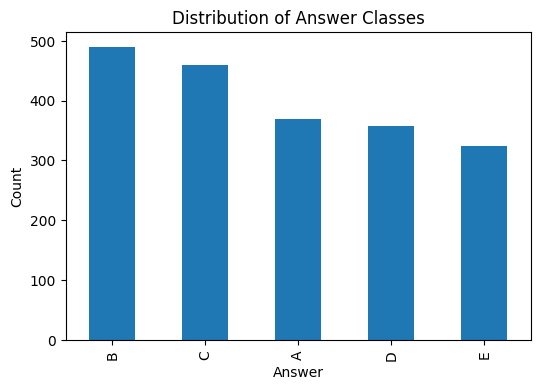

In [13]:
plt.figure(figsize=(6,4))

answer_counts.plot(kind="bar")

plt.title("Distribution of Answer Classes")

plt.xlabel("Answer")

plt.ylabel("Count")

plt.show()

##  text Exploratory Data Analysis (EDA)
#### in normal EDA, we analyze numbers.
Example:
Salary
Age
Height
**But in NLP, our data is text.**
So we analyze things like:

* Number of words
* Numberof characters
* Sentence length
* Vocabulary
* Frequent words
* Stop words
* Distribution of text lengths



In [14]:
# ===========================================
# CHARACTER LENGTH OF QUESTIONS
# ===========================================

train["prompt_char_length"] = train["prompt"].str.len()

train[["prompt", "prompt_char_length"]].head()

,prompt,prompt_char_length
0,Pick the best possible answer: What is Martin ...,142
1,What is accelerator-based light-ion fusion?,43
2,Determine the correct option: What is the term...,182
3,Select the most accurate option: What is Marti...,129
4,Identify the correct statement: What is the co...,110


In [15]:
# ===========================================
# WORD COUNT
# ===========================================

train["prompt_word_count"] = (
    train["prompt"]
    .str.split()
    .str.len()
)

train[["prompt", "prompt_word_count"]].head()

,prompt,prompt_word_count
0,Pick the best possible answer: What is Martin ...,22
1,What is accelerator-based light-ion fusion?,5
2,Determine the correct option: What is the term...,27
3,Select the most accurate option: What is Marti...,19
4,Identify the correct statement: What is the co...,15


In [16]:
# ===========================================
# STATISTICS
# ===========================================

train["prompt_word_count"].describe()

count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_word_count, dtype: float64

#### Distribution of Question Length


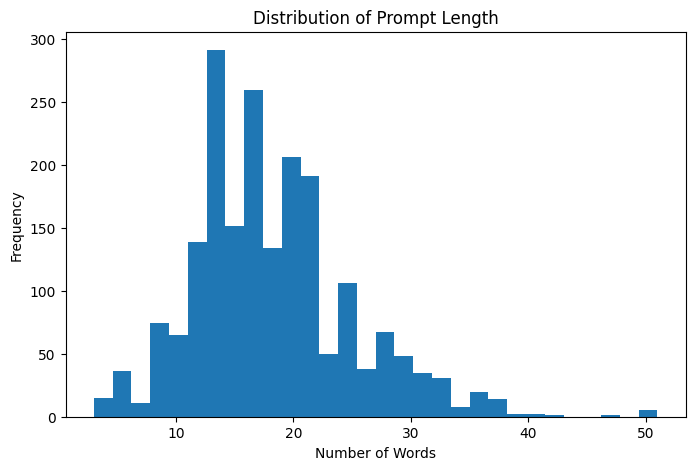

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    train["prompt_word_count"],
    bins=30
)

plt.title("Distribution of Prompt Length")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

In [18]:
# Longest Question
# Always inspect the extreme cases.

longest_idx = train["prompt_word_count"].idxmax()

train.loc[
    longest_idx,
    ["prompt", "prompt_word_count"]
]

prompt               Select the most accurate option: What is one o...
prompt_word_count                                                   51
Name: 1484, dtype: object

In [19]:
# shortest questions 

shortest_idx = train["prompt_word_count"].idxmin()

train.loc[
    shortest_idx,
    ["prompt", "prompt_word_count"]
]

prompt               What is emissivity?
prompt_word_count                      3
Name: 479, dtype: object

In [20]:
# analysing the options length 

option_columns = ["A", "B", "C", "D", "E"]

for col in option_columns:
    train[f"{col}_length"] = train[col].str.len()

In [21]:
# avg length of each options 
for col in option_columns:
    print(
        col,
        ":",
        train[f"{col}_length"].mean()
    )

A : 164.0915
B : 166.6165
C : 167.227
D : 162.5635
E : 164.23


# advanced test eda ( NLP ) 
Until now, we have treated every question as just a sentence.
Now we will study the language inside those sentences.
* e'll answer questions like:
* Which words appear most frequently?
* Should we remove stopwords?
* Should we remove punctuation?
* Should we lowercase everything?
* What is tokenization?
* What is vocabulary?
* What is an n-gram?

In [22]:
# ===========================================
# NLP LIBRARIES
# ===========================================

import re
import string
from collections import Counter

from wordcloud import WordCloud

import nltk

from nltk.corpus import stopwords

from nltk.tokenize import word_tokenize

from nltk.util import ngrams

nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
# now we will create one text column 
train["combined_text"] = (
    train["prompt"] + " "
    + train["A"] + " "
    + train["B"] + " "
    + train["C"] + " "
    + train["D"] + " "
    + train["E"]
)

In [24]:
train["clean_text"] = (
    train["combined_text"]
    .str.lower()
)

In [25]:
def remove_punctuation(text):

    return text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

train["clean_text"] = train["clean_text"].apply(remove_punctuation)

In [26]:
train["tokens"] = (
    train["clean_text"]
    .apply(word_tokenize)
)

In [27]:
all_words = []

for tokens in train["tokens"]:
    all_words.extend(tokens)

vocabulary = set(all_words)

print("Vocabulary Size :", len(vocabulary))

Vocabulary Size : 3095


In [28]:
word_frequency = Counter(all_words)

word_frequency.most_common(20)

[('the', 27238),
 ('of', 14606),
 ('a', 11765),
 ('is', 10182),
 ('and', 6939),
 ('in', 6660),
 ('to', 6298),
 ('that', 4428),
 ('by', 2153),
 ('an', 2054),
 ('which', 1944),
 ('on', 1936),
 ('are', 1904),
 ('from', 1833),
 ('or', 1832),
 ('as', 1810),
 ('what', 1809),
 ('for', 1775),
 ('with', 1692),
 ('it', 1414)]

In [29]:
stop_words = set(stopwords.words("english"))

filtered_words = [
    word
    for word in all_words
    if word not in stop_words
]

**Word clouds give a quick visual intuition about the dominant vocabulary in the dataset. They are especially useful during EDA, though they are not used directly for model training.******

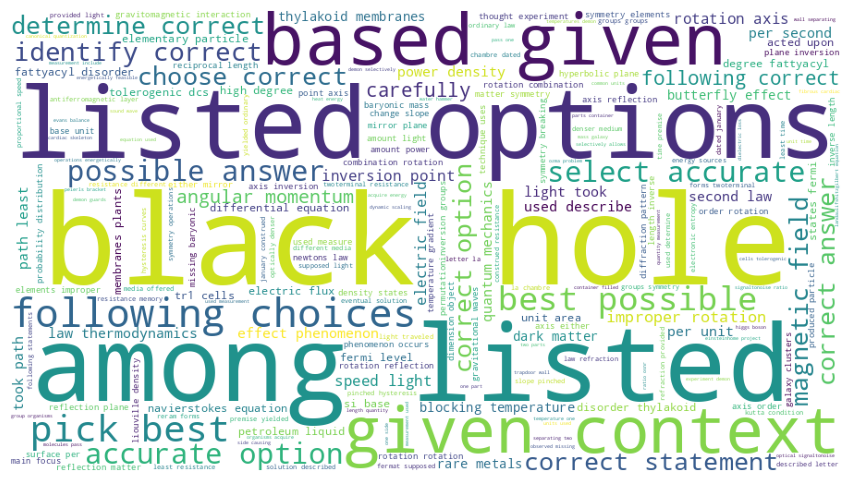

In [30]:
wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(" ".join(filtered_words))

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [31]:
bigrams = list(
    ngrams(filtered_words, 2)
)

Counter(bigrams).most_common(20)

[(('black', 'hole'), 390),
 (('among', 'listed'), 388),
 (('listed', 'options'), 388),
 (('based', 'given'), 376),
 (('given', 'context'), 376),
 (('following', 'choices'), 369),
 (('pick', 'best'), 316),
 (('best', 'possible'), 316),
 (('possible', 'answer'), 316),
 (('select', 'accurate'), 309),
 (('accurate', 'option'), 309),
 (('identify', 'correct'), 302),
 (('correct', 'statement'), 302),
 (('determine', 'correct'), 299),
 (('correct', 'option'), 299),
 (('choose', 'correct'), 292),
 (('correct', 'answer'), 292),
 (('following', 'correct'), 282),
 (('magnetic', 'field'), 260),
 (('angular', 'momentum'), 249)]

In [32]:
trigrams = list(
    ngrams(filtered_words, 3)
)

Counter(trigrams).most_common(20)

[(('among', 'listed', 'options'), 388),
 (('based', 'given', 'context'), 376),
 (('pick', 'best', 'possible'), 316),
 (('best', 'possible', 'answer'), 316),
 (('select', 'accurate', 'option'), 309),
 (('identify', 'correct', 'statement'), 302),
 (('determine', 'correct', 'option'), 299),
 (('choose', 'correct', 'answer'), 292),
 (('light', 'took', 'path'), 160),
 (('took', 'path', 'least'), 160),
 (('second', 'law', 'thermodynamics'), 158),
 (('states', 'fermi', 'level'), 120),
 (('high', 'degree', 'fattyacyl'), 120),
 (('degree', 'fattyacyl', 'disorder'), 120),
 (('fattyacyl', 'disorder', 'thylakoid'), 120),
 (('disorder', 'thylakoid', 'membranes'), 120),
 (('thylakoid', 'membranes', 'plants'), 120),
 (('per', 'unit', 'area'), 112),
 (('improper', 'rotation', 'combination'), 105),
 (('rotation', 'combination', 'rotation'), 105)]

# Now , we will work on the clisical machine learning model 